# Unified Control Framework Demonstration
This notebook illustrates simplified computational tests of:
- Perceptual Control Theory (PCT)
- Free Energy Principle (FEP)
- Sparse coding dynamics


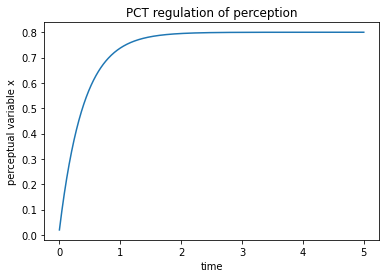

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# simple PCT control loop
dt = 0.01
T = 5.0
steps = int(T/dt)

r = 1.0  # reference
x = 0.0  # perception
a = 0.0  # action
k = 2.0  # gain

xs = []

for t in range(steps):
    e = r - x
    a = k * e
    x = x + dt*(a - 0.5*x)  # environment dynamics
    xs.append(x)

plt.plot(np.linspace(0,T,steps), xs)
plt.title("PCT regulation of perception")
plt.xlabel("time")
plt.ylabel("perceptual variable x")
plt.show()


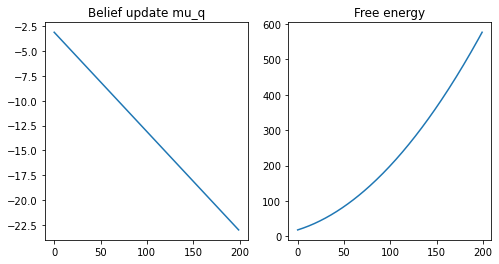

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# simple linear generative model
# o = s + noise
# prior s ~ N(mu_p,1)

mu_p = 0.0
o = 2.0  # observation

# variational parameter
mu_q = -3.0

def free_energy(mu_q):
    # F approx KL(q||p) - E_q[log p(o|s)]
    kl = 0.5*( (mu_q-mu_p)**2 )
    accuracy = -0.5*(o-mu_q)**2
    return kl - accuracy

mus=[]
Fs=[]

for _ in range(200):
    grad = (mu_q - mu_p) + (o - mu_q)
    mu_q -= 0.05 * grad
    mus.append(mu_q)
    Fs.append(free_energy(mu_q))

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(mus)
plt.title("Belief update mu_q")
plt.subplot(1,2,2)
plt.plot(Fs)
plt.title("Free energy")
plt.show()


In [3]:

import numpy as np

# simple sparse representation test
np.random.seed(0)
D = np.random.randn(10,3)
x = np.random.randn(10)

# L1 coordinate descent
a = np.zeros(3)
lr = 0.1
lam = 0.1

for _ in range(200):
    grad = -D.T@(x - D@a)
    a = a - lr*grad
    a = np.sign(a)*np.maximum(np.abs(a)-lr*lam,0)

a


array([-0.09038614,  0.19796942, -0.60268994])